In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys 
sys.path.append('..')

import matplotlib.pyplot as plt 
import numpy as np

import hippocampalseq as hse
import hippocampalseq.preprocessing as hsep
import hippocampalseq.models as hsem 
import hippocampalseq.utils as hseu

time_window_ms = 3 
time_window_s  = 3 / 1000
bin_size = 4

data_path = os.path.realpath("../data")
rat_name = "Janni"
session = 1

In [3]:
rat_data = hsep.load_clean_data(
    data_path, 
    rat_name, 
    session
)

[ 8.6018553  20.61032439 15.21783831 27.9185658 ]


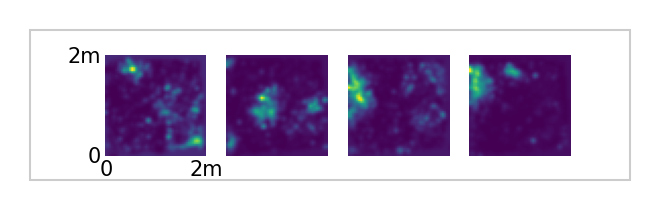

In [4]:
place_fields = hsep.calculate_placefields(rat_data, bin_size_cm=bin_size)
rat_data.place_field_data = place_fields

print(np.max(place_fields.place_fields[:4], axis=(1,2)))
hse.plot_placefields(place_fields, [0,1,2,3])

In [5]:
theta_data = hsep.process_theta(rat_data)

(0.0, 200.0)

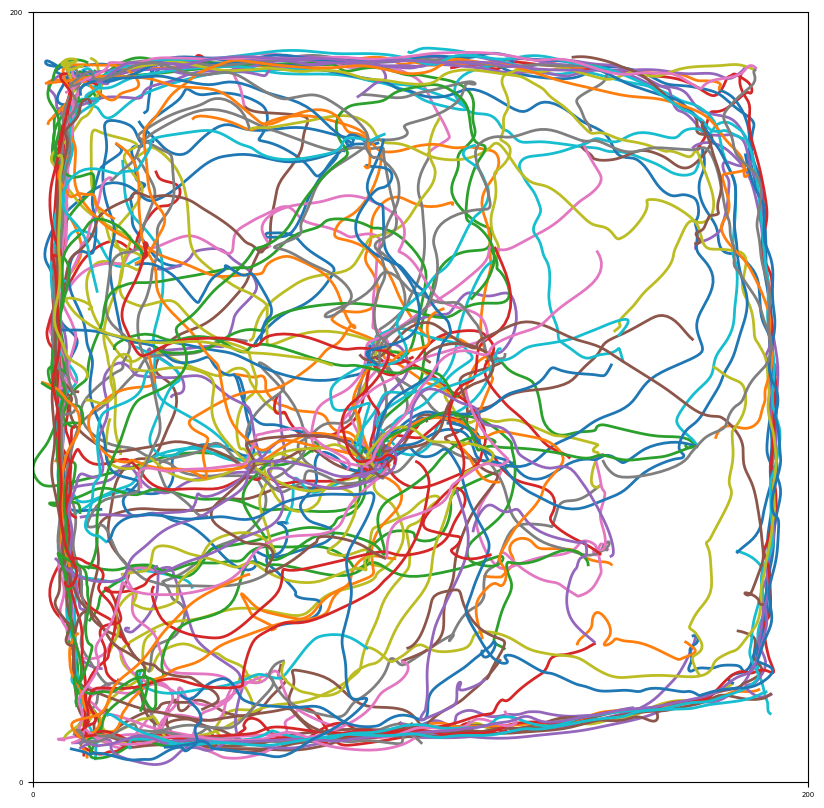

In [6]:
plt.figure(figsize=(10,10))
for ts in theta_data.theta_spikes:
    plt.plot(ts.true_trajectory[:,0], ts.true_trajectory[:,1])

plt.xticks([0,200])
plt.xlim([0,200])
plt.yticks([0,200])
plt.ylim([0,200])

In [ ]:
decoder = hsem.BayesianMAP(place_fields.place_fields, time_window_s)
decoded_trajectory = decoder.fit([s.spikemat for s in theta_data.theta_spikes]).trajectories

In [ ]:
num = 10
plt.subplot(1,2,1)
plt.plot(decoded_trajectory[num][:,0], decoded_trajectory[num][:,1])
plt.subplot(1,2,2)
plt.plot(theta_data.theta_spikes[num].true_trajectory[:,0], theta_data.theta_spikes[num].true_trajectory[:,1])